# Results from SSNAP coeffs DEAP runs

Visually inspect the admissions coefficients from the genetic algorithm results. Calculate r-squared values to decide which coefficients are the best.

__Inputs:__

+ Best individuals for each generation of each run of the genetic algorithm.
+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.
+ SSNAP-derived coefficients for converting scale factors into probability coefficients.

__Results:__

+ Calculated r-squared values for the fits of calculated to observed admission numbers.
+ Images of the resulting coefficients.

__Method:__

For each run of the genetic algorithm, keep a copy of the best set of coefficients in the final generation.

Calculate the r-squared values associated with each set of coefficients.

Plot the coefficients to gauge the range of values.

Pick out the "best" values, where the r-squared value rounds to the same as the best r-squared value.

## Code setup

In [1]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

## Load data

List of directories to load from:

In [2]:
results_dirs = sorted([d for d in os.listdir(os.path.join('genetic_algorithms', 'outputs')) if d.startswith('randomseed')])

Load all dataframes and store the final generation's best individual:

In [3]:
dfs_to_merge = []
results_dirs_to_merge = []

for results_dir in results_dirs:
    path_to_results = os.path.join('genetic_algorithms', 'outputs', results_dir, 'best_inds_by_gen.csv')
    try:
        df = pl.read_csv(path_to_results)
        final_gen_best = df[-1]
        dfs_to_merge.append(final_gen_best)
        results_dirs_to_merge.append(results_dir)
    except FileNotFoundError:
        pass

Combine all dataframes:

In [4]:
df_best_gens = pl.concat(dfs_to_merge)
# Add a column to label results directory:
df_best_gens = df_best_gens.with_columns(pl.Series('dir', results_dirs_to_merge))
# Move label to first column:
df_best_gens = df_best_gens.drop('dir').insert_column(0, df_best_gens.get_column('dir'))

In [5]:
df_best_gens.sort('fitness')

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed34""",64.0,1.4,1.4,1.394065,1.4,1.2,1.199796,1.198922,1.2,1.029424,1.148443,1.0,1.074962,1.0,1.0,1.0,0.876973,0.936223,0.965011,1.0,0.979912,0.8,0.793699,0.8,0.8,0.979912,238.554329
"""randomseed52""",82.0,1.4,1.4,1.333046,1.3888,1.152121,1.211833,1.246261,1.2,1.2,1.089344,1.0,1.0,1.0,0.98302,1.046246,0.941918,0.953279,1.0,0.897459,1.0,0.723373,0.8,0.8,0.796607,0.992706,238.840075
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371
"""randomseed37""",48.0,1.4,1.4,1.435064,1.446943,1.180988,1.224822,1.232977,1.2,1.037925,1.16555,1.036308,1.179358,1.001183,1.026986,1.002612,0.866206,0.8,0.940265,0.943467,1.0,0.743405,0.794525,0.798391,0.8,0.952125,239.384272
"""randomseed09""",50.0,1.451841,1.4,1.4,1.2,1.172135,1.2,1.2,1.154271,1.195485,1.101842,0.96287,0.996789,1.0,1.012757,1.001787,0.937433,0.989814,0.997214,0.89255,0.995301,0.7162,0.805322,0.801156,0.89255,0.995301,239.468844
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed38""",37.0,1.483204,1.458408,1.335886,1.424668,1.217526,1.136982,1.14608,1.2,1.068963,1.173937,0.979278,1.0,1.0,1.0,1.0,0.927663,1.0,1.0,0.917982,0.960155,0.761365,0.831799,0.8,0.863516,0.960155,243.161978
"""randomseed83""",25.0,1.322617,1.350996,1.341558,1.4,1.278371,1.155608,1.2,1.2,1.2,1.184784,1.0,1.067706,1.0,0.9933,1.0,1.0,1.0,0.994465,0.874328,1.0,0.8,0.741061,0.8,0.8,0.883632,243.415986
"""randomseed59""",22.0,1.263284,1.4,1.4,1.39008,1.4,1.2,1.2,1.2,1.122105,1.2,1.061701,1.0,1.0,1.0,0.987216,0.957253,0.985393,0.971896,0.932564,0.94197,0.8,0.8,0.8,0.8,0.875508,243.500174


## Load admissions data

In [6]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [7]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6710.0928,476.4916,450.0672,359.7128,528.488,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,4953.6078,383.4452,513.4716,326.3928,459.0728,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5487.59,432.39,413.22,298.91,469.31,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8193.7557,470.9055,443.5626,371.6609,646.1026,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6516.4218,509.0022,571.242,362.355,564.4212,0.6,0.8


Pick out column names for the health and age proportions:

In [8]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [9]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [10]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Admissions data:

In [11]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

Starting SSNAP coefficients:

In [13]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [14]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [15]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

## Calculate r-squared

In [16]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [17]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [18]:
def calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists):
    list_r2 = []
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = np.array(coeffs[(i*5):(i*5)+5]) * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)
        observed_here = admissions_lists[i]
        r2 = calculate_rsquared(observed_here, yhat)
        list_r2.append(r2)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    list_r2.append(r2)
    return list_r2

Calculate r-squared values and store in dictionaries:

In [19]:
dict_r2 = {}
dict_r2_qs = [{}, {}, {}, {}, {}]

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()

    list_r2 = calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists)
    for i in range(len(dict_r2_qs)):
        dict_r2_qs[i][results_dir] = list_r2[i]
    dict_r2[results_dir] = list_r2[-1]

Convert dictionaries to dataframes:

In [20]:
df_r2 = pl.from_dict(dict_r2).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_all'})
df_r2_q00 = pl.from_dict(dict_r2_qs[0]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q00'})
df_r2_q02 = pl.from_dict(dict_r2_qs[1]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q02'})
df_r2_q04 = pl.from_dict(dict_r2_qs[2]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q04'})
df_r2_q06 = pl.from_dict(dict_r2_qs[3]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q06'})
df_r2_q08 = pl.from_dict(dict_r2_qs[4]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q08'})

Combine r-squared dataframes with the main results dataframe:

In [21]:
for df in [df_r2, df_r2_q00, df_r2_q02, df_r2_q04, df_r2_q06, df_r2_q08]:
    df_best_gens = df_best_gens.join(df, on='dir')

Check results:

In [22]:
df_best_gens.sort('r2_all', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709
"""randomseed41""",35.0,1.4,1.394472,1.491289,1.2,1.176441,1.253797,1.173068,1.080715,1.050118,1.125261,1.0,1.053346,1.0,1.0,1.0,0.8,0.961484,1.0,1.0,1.0,0.8,0.8,0.8,0.908886,0.982146,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415
"""randomseed47""",51.0,1.509935,1.288461,1.327035,1.33879,1.2,1.113402,1.198,1.2,1.125237,1.12347,0.992264,1.05886,1.0,1.016319,1.0,0.902984,0.926627,0.939284,0.958704,0.988581,0.755995,0.889544,0.863378,0.819027,0.988581,240.268793,0.591575,0.494178,0.579535,0.634652,0.607894,0.620379
"""randomseed65""",58.0,1.384298,1.707645,1.6,1.088252,1.180937,1.202216,1.18193,1.2,1.088252,1.110136,0.988208,1.0,1.0,1.0,1.019277,0.912351,0.987298,0.96661,0.970934,0.99073,0.79201,0.6,0.697933,0.969452,0.981982,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604
"""randomseed81""",30.0,1.474497,1.4,1.4,1.107886,1.2,1.106899,1.2,1.183136,1.107886,1.184099,0.995979,1.0,1.0,1.0,1.02665,0.89788,0.974566,0.993429,1.0,0.950901,0.799854,0.790744,0.8,0.928723,0.950901,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed60""",23.0,1.4,1.391014,1.4,1.4,1.269015,1.187818,1.2,1.2,1.2,1.2,1.0,1.0,0.977735,1.0,1.0,0.890014,1.0,0.977735,0.880251,0.942276,0.795935,0.8,0.8,0.8,0.927973,241.734051,0.58279,0.486058,0.562332,0.632282,0.602063,0.609088
"""randomseed83""",25.0,1.322617,1.350996,1.341558,1.4,1.278371,1.155608,1.2,1.2,1.2,1.184784,1.0,1.067706,1.0,0.9933,1.0,1.0,1.0,0.994465,0.874328,1.0,0.8,0.741061,0.8,0.8,0.883632,243.415986,0.581689,0.491031,0.56937,0.63435,0.60288,0.588041
"""randomseed98""",34.0,1.4,1.385308,1.309416,1.4,1.32992,1.2,1.2,1.068135,1.041676,1.215415,1.0,1.0,1.0,1.0,0.999982,0.868196,1.0,1.0,0.953337,0.999399,0.8,0.80838,0.909831,0.8,0.838122,243.918821,0.581656,0.481074,0.578695,0.63315,0.605913,0.585607


In [23]:
r2_best = df_best_gens['r2_all'].max()

r2_best

0.5919103791585711

## Check best individuals

Plot to gauge the range of values:

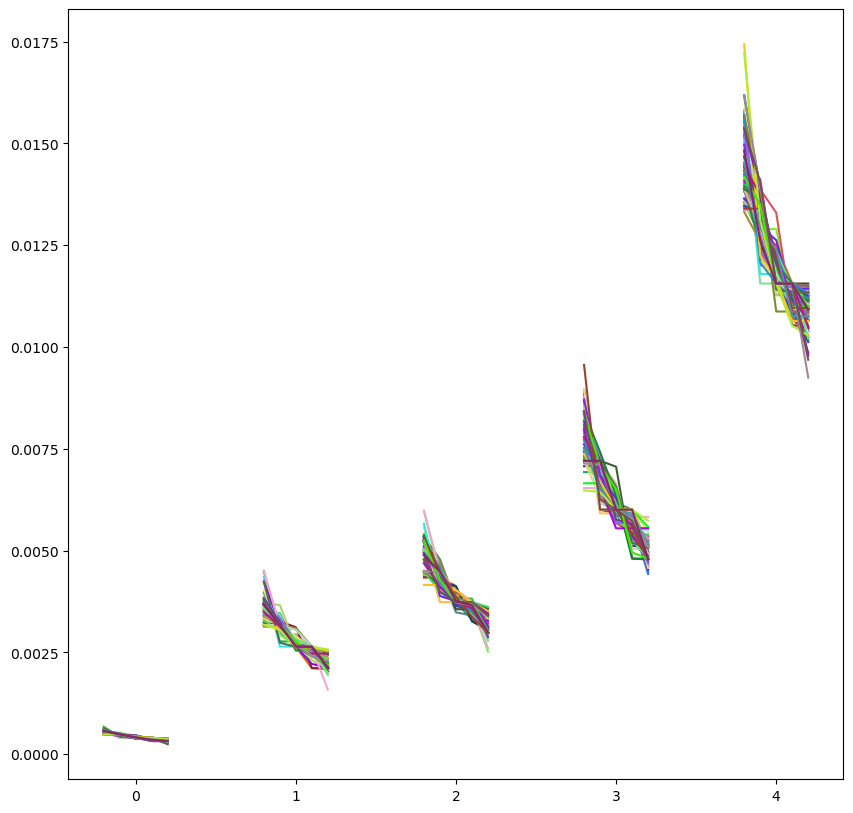

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    colour = np.random.rand(3,)
    zorder = 5
    alpha = 1.0
    # else:
    #     colour = 'silver'
    #     zorder = 4
    #     alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1
plt.show()

Check mean, std, min, max values:

In [25]:
pl.concat([
    df_best_gens.mean().select(pl.col(float).round(2)),
    df_best_gens.std().select(pl.col(float).round(2)),
    df_best_gens.min().select(pl.col(float).round(2)),
    df_best_gens.max().select(pl.col(float).round(2)),
])

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
41.19,1.38,1.38,1.35,1.32,1.25,1.16,1.2,1.17,1.14,1.14,1.01,1.02,1.01,1.0,1.01,0.93,0.98,0.97,0.94,0.98,0.81,0.82,0.83,0.83,0.94,240.9,0.59,0.49,0.58,0.63,0.61,0.61
11.94,0.08,0.09,0.09,0.1,0.07,0.06,0.05,0.05,0.07,0.05,0.04,0.04,0.03,0.03,0.03,0.06,0.04,0.03,0.05,0.02,0.06,0.06,0.06,0.05,0.04,1.05,0.0,0.0,0.0,0.0,0.0,0.01
19.0,1.2,1.19,1.11,1.08,1.15,1.0,1.0,1.0,0.99,1.0,0.93,0.96,0.93,0.92,0.94,0.79,0.8,0.87,0.8,0.91,0.6,0.6,0.68,0.74,0.8,238.55,0.58,0.47,0.56,0.63,0.6,0.58
82.0,1.69,1.71,1.6,1.59,1.51,1.33,1.39,1.28,1.24,1.22,1.15,1.18,1.11,1.18,1.15,1.02,1.0,1.02,1.0,1.0,0.96,0.97,0.97,0.97,1.0,243.92,0.59,0.5,0.58,0.64,0.61,0.62


In [26]:
# df_best_gens.sort('fitness')
df_best_gens.sort('fitness').select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
64.0,1.4,1.4,1.39,1.4,1.2,1.2,1.2,1.2,1.03,1.15,1.0,1.07,1.0,1.0,1.0,0.88,0.94,0.97,1.0,0.98,0.8,0.79,0.8,0.8,0.98,238.55,0.59,0.49,0.58,0.63,0.61,0.62
82.0,1.4,1.4,1.33,1.39,1.15,1.21,1.25,1.2,1.2,1.09,1.0,1.0,1.0,0.98,1.05,0.94,0.95,1.0,0.9,1.0,0.72,0.8,0.8,0.8,0.99,238.84,0.59,0.49,0.58,0.64,0.61,0.62
59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.29,0.59,0.5,0.58,0.64,0.61,0.62
48.0,1.4,1.4,1.44,1.45,1.18,1.22,1.23,1.2,1.04,1.17,1.04,1.18,1.0,1.03,1.0,0.87,0.8,0.94,0.94,1.0,0.74,0.79,0.8,0.8,0.95,239.38,0.59,0.49,0.58,0.64,0.61,0.61
50.0,1.45,1.4,1.4,1.2,1.17,1.2,1.2,1.15,1.2,1.1,0.96,1.0,1.0,1.01,1.0,0.94,0.99,1.0,0.89,1.0,0.72,0.81,0.8,0.89,1.0,239.47,0.59,0.5,0.58,0.63,0.61,0.62
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
37.0,1.48,1.46,1.34,1.42,1.22,1.14,1.15,1.2,1.07,1.17,0.98,1.0,1.0,1.0,1.0,0.93,1.0,1.0,0.92,0.96,0.76,0.83,0.8,0.86,0.96,243.16,0.59,0.48,0.58,0.63,0.61,0.62
25.0,1.32,1.35,1.34,1.4,1.28,1.16,1.2,1.2,1.2,1.18,1.0,1.07,1.0,0.99,1.0,1.0,1.0,0.99,0.87,1.0,0.8,0.74,0.8,0.8,0.88,243.42,0.58,0.49,0.57,0.63,0.6,0.59
22.0,1.26,1.4,1.4,1.39,1.4,1.2,1.2,1.2,1.12,1.2,1.06,1.0,1.0,1.0,0.99,0.96,0.99,0.97,0.93,0.94,0.8,0.8,0.8,0.8,0.88,243.5,0.58,0.48,0.57,0.63,0.61,0.59


## "Best" options

Pick out only the individuals where their r-squared value rounds to the same value as the best r-squared available.

In [27]:
df_best_gens_topr2 = df_best_gens.filter(np.round(df_best_gens['r2_all'], 3) == np.round(r2_best, 3)).sort('r2_all', descending=True)

In [28]:
len(df_best_gens_topr2)

5

View coeffs:

In [29]:
df_best_gens_topr2.select(pl.col(float).round(2))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
59.0,1.46,1.7,1.21,1.19,1.2,1.19,1.18,1.2,1.19,1.1,0.96,1.0,1.0,1.0,1.08,0.85,0.8,0.97,1.0,1.0,0.81,0.79,0.9,0.8,0.93,239.29,0.59,0.5,0.58,0.64,0.61,0.62
35.0,1.4,1.39,1.49,1.2,1.18,1.25,1.17,1.08,1.05,1.13,1.0,1.05,1.0,1.0,1.0,0.8,0.96,1.0,1.0,1.0,0.8,0.8,0.8,0.91,0.98,240.14,0.59,0.49,0.58,0.63,0.61,0.62
51.0,1.51,1.29,1.33,1.34,1.2,1.11,1.2,1.2,1.13,1.12,0.99,1.06,1.0,1.02,1.0,0.9,0.93,0.94,0.96,0.99,0.76,0.89,0.86,0.82,0.99,240.27,0.59,0.49,0.58,0.63,0.61,0.62
58.0,1.38,1.71,1.6,1.09,1.18,1.2,1.18,1.2,1.09,1.11,0.99,1.0,1.0,1.0,1.02,0.91,0.99,0.97,0.97,0.99,0.79,0.6,0.7,0.97,0.98,240.48,0.59,0.49,0.58,0.64,0.61,0.62
30.0,1.47,1.4,1.4,1.11,1.2,1.11,1.2,1.18,1.11,1.18,1.0,1.0,1.0,1.0,1.03,0.9,0.97,0.99,1.0,0.95,0.8,0.79,0.8,0.93,0.95,241.68,0.59,0.5,0.58,0.64,0.61,0.62


Check mean, std, min and max of these best individuals:

In [30]:
pl.concat([
    df_best_gens_topr2.mean().select(pl.col(float).round(2)),
    df_best_gens_topr2.std().select(pl.col(float).round(2)),
    df_best_gens_topr2.min().select(pl.col(float).round(2)),
    df_best_gens_topr2.max().select(pl.col(float).round(2)),
])

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
46.6,1.45,1.5,1.4,1.19,1.19,1.17,1.19,1.17,1.11,1.13,0.99,1.02,1.0,1.0,1.03,0.87,0.93,0.97,0.99,0.99,0.79,0.77,0.81,0.89,0.97,240.37,0.59,0.5,0.58,0.64,0.61,0.62
13.35,0.05,0.19,0.15,0.1,0.01,0.06,0.01,0.05,0.05,0.03,0.02,0.03,0.0,0.01,0.03,0.05,0.08,0.02,0.02,0.02,0.02,0.11,0.08,0.07,0.03,0.86,0.0,0.0,0.0,0.0,0.0,0.0
30.0,1.38,1.29,1.21,1.09,1.18,1.11,1.17,1.08,1.05,1.1,0.96,1.0,1.0,1.0,1.0,0.8,0.8,0.94,0.96,0.95,0.76,0.6,0.7,0.8,0.93,239.29,0.59,0.49,0.58,0.63,0.61,0.62
59.0,1.51,1.71,1.6,1.34,1.2,1.25,1.2,1.2,1.19,1.18,1.0,1.06,1.0,1.02,1.08,0.91,0.99,1.0,1.0,1.0,0.81,0.89,0.9,0.97,0.99,241.68,0.59,0.5,0.58,0.64,0.61,0.62


Plot these best individuals:

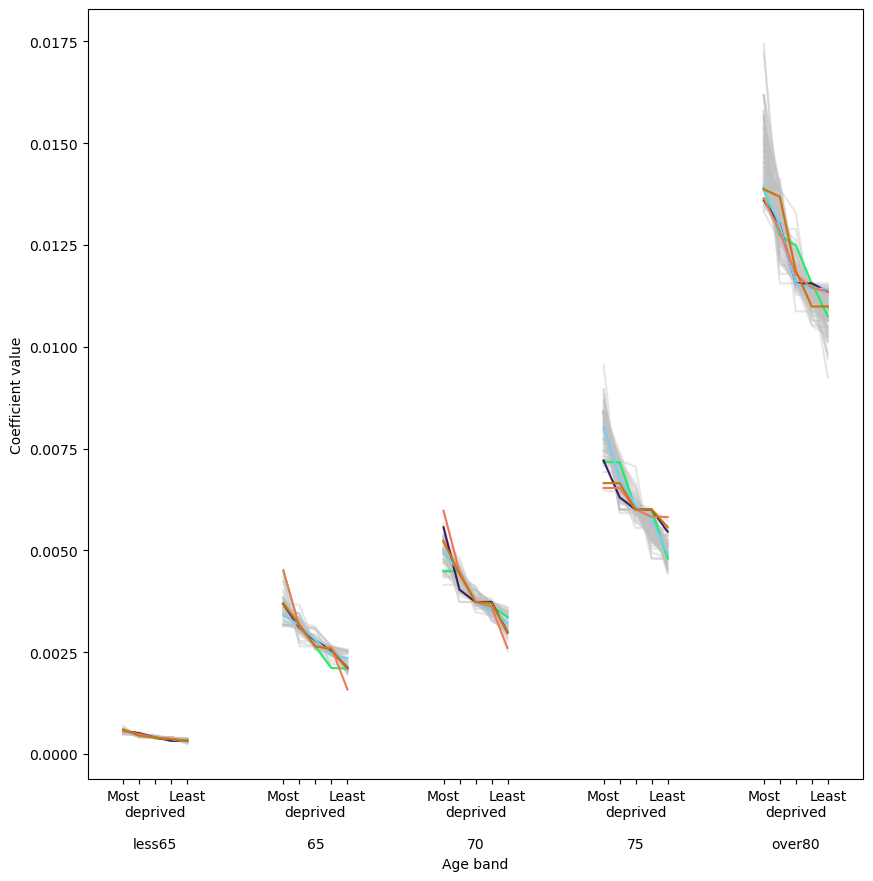

In [31]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        zorder = 5
        alpha = 1.0
    else:
        colour = 'silver'
        zorder = 4
        alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1

ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')
plt.show()